# Import the Libraries

In [1]:
# 1. Install Dependencies (REQUIRES INTERNET)
!pip install "protobuf<3.21"
!pip install onnx2tf onnx sng4onnx onnx-graphsurgeon tensorflow onnxsim
!pip install ai-edge-litert

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.7/468.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which i

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import subprocess
from tqdm import tqdm  # Import progress bar library

2025-12-14 10:10:27.730303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765707027.997760      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765707028.079340      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load the Model

In [3]:
TEST_DIR = '/kaggle/input/cnn-dataset/CNN Dataset/Test '  # <--- REPLACE THIS with your actual test folder path
WEIGHTS_PATH = '/kaggle/input/macro-facial-emotion-recognition/pytorch/default/1/resnet_emotion_model.pth' 
BATCH_SIZE = 32
IMG_SIZE = 48

# CRITICAL: This specific order comes from your notebook's os.listdir output
# 0=Surprise, 1=Fear, 2=Angry, 3=Neutral, 4=Sad, 5=Disgust, 6=Happy
CLASSES = ['Surprise', 'Fear', 'Angry', 'Neutral', 'Sad', 'Disgust', 'Happy'] 
NUM_CLASSES = len(CLASSES)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Enforcing Notebook Class Map: {CLASSES}")

# ==========================================
# 2. MODEL DEFINITION
# ==========================================
class EfficientResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(EfficientResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(residual)
        out = self.relu(out)
        return out

class EfficientResNet18(nn.Module):
    def __init__(self, num_classes=7):
        super(EfficientResNet18, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.maxpool = nn.Identity()
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_classes)
        self._initialize_weights()

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        layers.append(EfficientResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(EfficientResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = EfficientResNet18(num_classes=NUM_CLASSES)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)

# Load ONLY the weights (state_dict) into the model
# The error showed the keys are hidden inside "model_state_dict"
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()
print("PyTorch Model Loaded Successfully.")

# Transforms
image_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# OPTIONAL: Use classes from the file if they exist to be 100% sure
if 'classes' in checkpoint:
    CLASSES = checkpoint['classes']
    print(f"Loaded Classes directly from file: {CLASSES}")
else:
    print(f"Using manual Notebook Class Map: {CLASSES}")

# Custom Data Loading to match Notebook's "os.listdir" behavior logic
test_images = []
test_labels = []

print("Loading Test Data...")
for label_idx, emotion in enumerate(CLASSES):
    emotion_path = os.path.join(TEST_DIR, emotion)
    if not os.path.exists(emotion_path):
        print(f"Warning: Folder {emotion} not found in test dir.")
        continue
        
    for image_file in os.listdir(emotion_path):
        if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(emotion_path, image_file)
            try:
                img = Image.open(image_path)
                img = image_transform(img)
                test_images.append(img)
                test_labels.append(label_idx)
            except Exception as e:
                print(f"Error loading {image_path}: {e}")

# Create DataLoader
if len(test_images) > 0:
    test_tensor_x = torch.stack(test_images)
    test_tensor_y = torch.tensor(test_labels, dtype=torch.long)
    test_dataset = TensorDataset(test_tensor_x, test_tensor_y)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print(f"Loaded {len(test_dataset)} test images.")
else:
    print("No images found! Check your TEST_DIR path.")

Using device: cpu
Enforcing Notebook Class Map: ['Surprise', 'Fear', 'Angry', 'Neutral', 'Sad', 'Disgust', 'Happy']
PyTorch Model Loaded Successfully.
Loaded Classes directly from file: ['Surprise', 'Fear', 'Angry', 'Neutral', 'Sad', 'Disgust', 'Happy']
Loading Test Data...
Loaded 14244 test images.


# Data Preprocessing

In [4]:
image_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Custom Data Loading to match Notebook's "os.listdir" behavior logic
# We force the label ID based on the CLASSES list order
test_images = []
test_labels = []

print("Loading Test Data with Notebook Mapping...")
for label_idx, emotion in enumerate(CLASSES):
    emotion_path = os.path.join(TEST_DIR, emotion)
    if not os.path.exists(emotion_path):
        print(f"Warning: Folder {emotion} not found in test dir.")
        continue
        
    for image_file in os.listdir(emotion_path):
        if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(emotion_path, image_file)
            try:
                img = Image.open(image_path)
                img = image_transform(img)
                test_images.append(img)
                test_labels.append(label_idx)
            except Exception as e:
                print(f"Error loading {image_path}: {e}")

# Create DataLoader
test_tensor_x = torch.stack(test_images)
test_tensor_y = torch.tensor(test_labels, dtype=torch.long)
test_dataset = TensorDataset(test_tensor_x, test_tensor_y)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Loaded {len(test_dataset)} test images.")

Loading Test Data with Notebook Mapping...
Loaded 14244 test images.


# Evaluate the PyTorch Model


--- PyTorch Evaluation ---
              precision    recall  f1-score   support

    Surprise       0.97      0.95      0.96      1628
        Fear       0.91      0.88      0.89      2042
       Angry       0.88      0.93      0.90      1918
     Neutral       0.91      0.92      0.92      2449
         Sad       0.92      0.90      0.91      2386
     Disgust       0.99      0.86      0.92       222
       Happy       0.96      0.97      0.96      3599

    accuracy                           0.93     14244
   macro avg       0.93      0.92      0.92     14244
weighted avg       0.93      0.93      0.93     14244



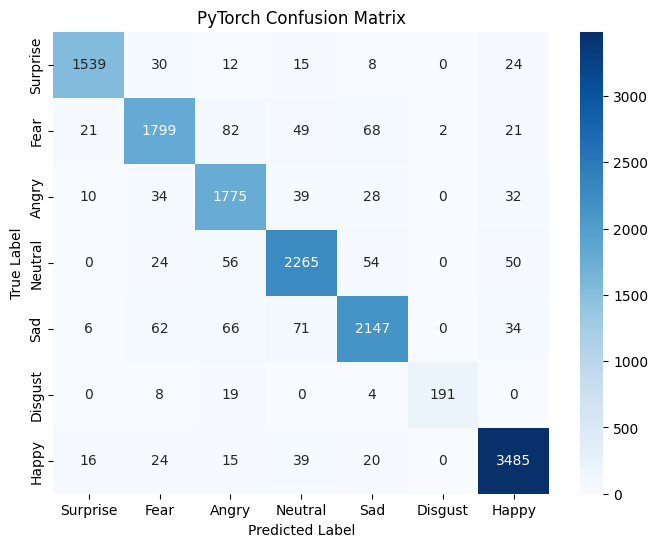

In [5]:
def evaluate_pytorch(model, loader):
    y_true = []
    y_pred = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    return y_true, y_pred

print("\n--- PyTorch Evaluation ---")
pt_true, pt_pred = evaluate_pytorch(model, test_loader)
print(classification_report(pt_true, pt_pred, target_names=CLASSES))

# Confusion Matrix
cm = confusion_matrix(pt_true, pt_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('PyTorch Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# CONVERT TO ONNX -> TF -> TFLITE

In [6]:
IMG_SIZE = 48
ONNX_PATH = "efficient_resnet18.onnx"
TF_PATH = "saved_model_tf"
TFLITE_PATH = "fer_model.tflite"

# Ensure model is in eval mode on the correct device
model.eval() 
model.to(device)

print("\n--- Starting Conversion ---")

print("1. Exporting PyTorch model to ONNX...")

dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)

torch.onnx.export(
    model, 
    dummy_input, 
    ONNX_PATH, 
    export_params=True,
    opset_version=11,          # Standard opset for compatibility
    do_constant_folding=True,
    input_names=['input'], 
    output_names=['output']
)
print(f"   ONNX exported to: {ONNX_PATH}")

try:
    print("2. Converting ONNX to TensorFlow SavedModel...")
    subprocess.check_call(f"onnx2tf -i {ONNX_PATH} -o {TF_PATH} -v info", shell=True)
    
    print("   TensorFlow SavedModel created.")

    print("3. Converting to TFLite (Quantized)...")
    converter = tf.lite.TFLiteConverter.from_saved_model(TF_PATH)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    
    with open(TFLITE_PATH, 'wb') as f:
        f.write(tflite_model)
    
    size_kb = os.path.getsize(TFLITE_PATH) / 1024
    print(f"SUCCESS: Model saved to {TFLITE_PATH}")
    print(f"Final Size: {size_kb:.2f} KB")
    
except subprocess.CalledProcessError as e:
    print(f"ONNX2TF Conversion failed: {e}")
except Exception as e:
    print(f"TFLite Conversion failed: {e}")


--- Starting Conversion ---
1. Exporting PyTorch model to ONNX...
   ONNX exported to: efficient_resnet18.onnx
2. Converting ONNX to TensorFlow SavedModel...


E0000 00:00:1765707547.687421      65 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765707547.695410      65 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



Model optimizing started ============================================================
Installing onnxruntime by `/usr/bin/python3 -m pip install onnxruntime`, please 
wait for a moment..

I0000 00:00:1765707568.013244      65 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1765707568.013483      65 single_machine.cc:361] Starting new session
W0000 00:00:1765707569.851183      65 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765707569.851244      65 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1765707571.853365      65 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1765707571.853530      65 single_machine.cc:361] Starting new session
W0000 00:00:1765707572.835529      65 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765707572.835578      65 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


   TensorFlow SavedModel created.
3. Converting to TFLite (Quantized)...


2025-12-14 10:19:35.364922: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


SUCCESS: Model saved to fer_model.tflite
Final Size: 10987.30 KB


W0000 00:00:1765707576.754434      13 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765707576.754481      13 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1765707576.815737      13 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


 # EVALUATE TFLITE MODEL

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



--- Evaluating TFLite Model: fer_model.tflite ---
Model Input Shape: [ 1 48 48  1]
Running Inference...


Processing Batches: 100%|██████████| 446/446 [11:03<00:00,  1.49s/batch]



Classification Report:
              precision    recall  f1-score   support

    Surprise       0.97      0.95      0.96      1628
        Fear       0.91      0.88      0.89      2042
       Angry       0.88      0.92      0.90      1918
     Neutral       0.91      0.93      0.92      2449
         Sad       0.92      0.90      0.91      2386
     Disgust       0.99      0.86      0.92       222
       Happy       0.96      0.97      0.96      3599

    accuracy                           0.93     14244
   macro avg       0.93      0.92      0.92     14244
weighted avg       0.93      0.93      0.93     14244



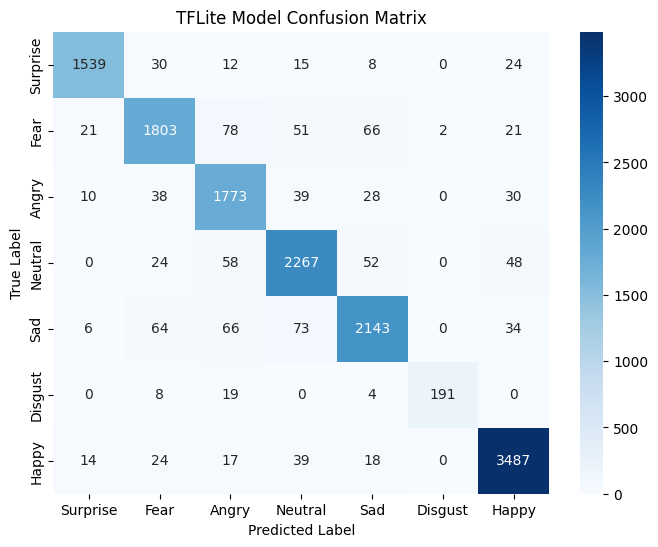

In [7]:

# Use the filename defined in the previous step
TFLITE_PATH = "fer_model.tflite"

if os.path.exists(TFLITE_PATH):
    print(f"\n--- Evaluating TFLite Model: {TFLITE_PATH} ---")
    
    # Load the TFLite model and allocate tensors
    interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # Check input shape requirements
    input_shape = input_details[0]['shape']
    print(f"Model Input Shape: {input_shape}")
    
    tf_pred = []
    tf_true = []
    
    print("Running Inference...")
    
    # Wrap the loader with tqdm for a progress bar
    # 'desc' sets the text description, 'unit' labels the units
    for inputs, labels in tqdm(test_loader, desc="Processing Batches", unit="batch"):
        # Convert to numpy and ensure float32
        inputs_np = inputs.numpy().astype(np.float32)
        
        for i in range(len(inputs_np)):
            # Prepare single image: (1, 48, 48) -> (1, 1, 48, 48)
            img = inputs_np[i]
            img = np.expand_dims(img, axis=0)
            
            # Check if TFLite model expects NHWC (1, 48, 48, 1) format
            # PyTorch data is NCHW (1, 1, 48, 48)
            if input_shape[3] == 1 and input_shape[1] == 48:
                img = np.transpose(img, (0, 2, 3, 1))
            
            # Set input tensor
            interpreter.set_tensor(input_details[0]['index'], img)
            
            # Run inference
            interpreter.invoke()
            
            # Get result
            out = interpreter.get_tensor(output_details[0]['index'])
            
            # Store predictions
            tf_pred.append(np.argmax(out))
            tf_true.append(labels[i].item())
            
    # --- Generate Report ---
    print("\nClassification Report:")
    print(classification_report(tf_true, tf_pred, target_names=CLASSES))
    
    # --- Plot Confusion Matrix ---
    cm_tf = confusion_matrix(tf_true, tf_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title('TFLite Model Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

else:
    print(f"Error: Model file '{TFLITE_PATH}' not found. Check the conversion step.")